# 1. Exploratory Data Analysis — Credit Card Fraud Dataset
**Project:** Enhancing Fraud Detection Using Synthetic Transactions Generated by Generative AI
**Domain:** Finance | **Dataset:** the genuine Kaggle "Credit Card Fraud Detection" dataset
(`Time`, `V1`...`V28` anonymized/PCA features, `Amount`, `Class`; 0=Non-Fraud, 1=Fraud).

## 1.1 Load data and check basic quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
df = pd.read_csv("../Data/creditcard.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()

Shape: (284807, 31)
Missing values: 0
Duplicate rows: 1081


## 1.2 Class imbalance check
This is the central challenge the whole project addresses.

In [1]:
class_counts = df['Class'].value_counts()
fraud_pct = df['Class'].mean() * 100
print(class_counts)
print(f"Fraud rate: {fraud_pct:.4f}%")
print(f"Imbalance ratio: 1 fraud per {int(class_counts[0]/class_counts[1])} legitimate transactions")

Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%
Imbalance ratio: 1 fraud per 577 legitimate transactions


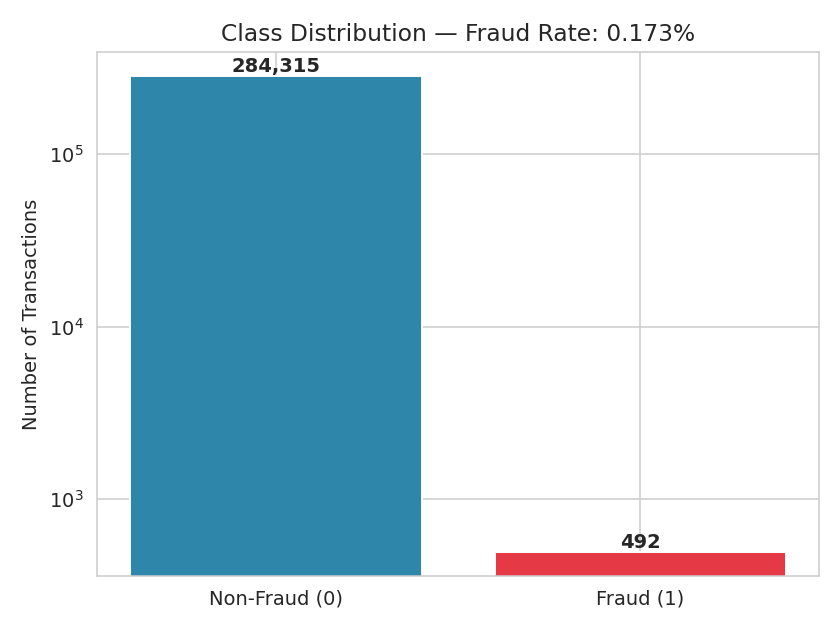

In [1]:
fig, ax = plt.subplots(figsize=(6,4.5))
colors = ["#2E86AB", "#E63946"]
bars = ax.bar(["Non-Fraud (0)","Fraud (1)"], class_counts.values, color=colors)
ax.set_yscale("log"); ax.set_ylabel("Number of Transactions")
ax.set_title(f"Class Distribution — Fraud Rate: {fraud_pct:.3f}%")
for b,v in zip(bars, class_counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

**Finding:** fraud makes up only 0.17% of transactions — 492 cases out of 284,807. This extreme imbalance is exactly the problem generative-AI-based augmentation is meant to help with.

## 1.3 Transaction Amount & Time patterns by class

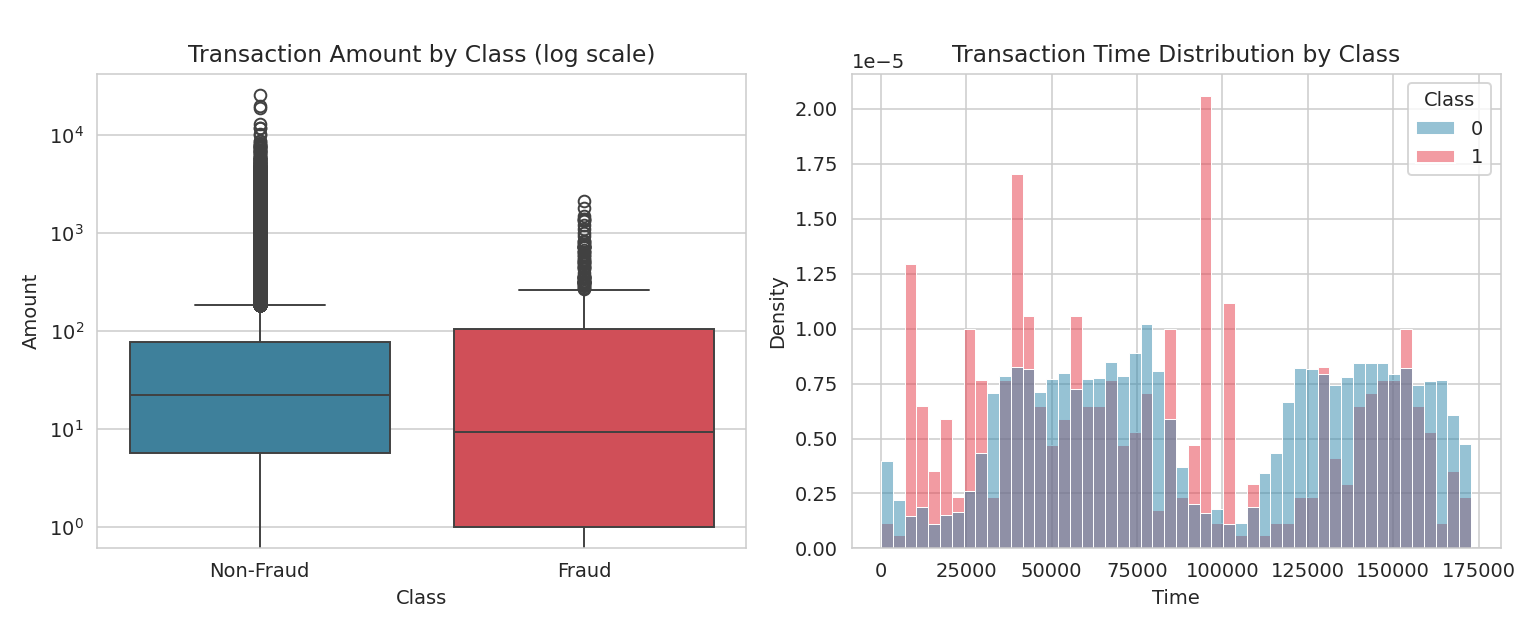

In [1]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0], hue="Class", palette=colors, legend=False)
axes[0].set_yscale("log"); axes[0].set_xticks([0,1]); axes[0].set_xticklabels(["Non-Fraud","Fraud"])
axes[0].set_title("Transaction Amount by Class (log scale)")
sns.histplot(data=df, x="Time", hue="Class", bins=50, stat="density", common_norm=False, palette=colors, ax=axes[1])
axes[1].set_title("Transaction Time Distribution by Class")
plt.tight_layout(); plt.show()

## 1.4 Correlation structure

Top 8 features correlated with Class:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
Name: Class, dtype: float64


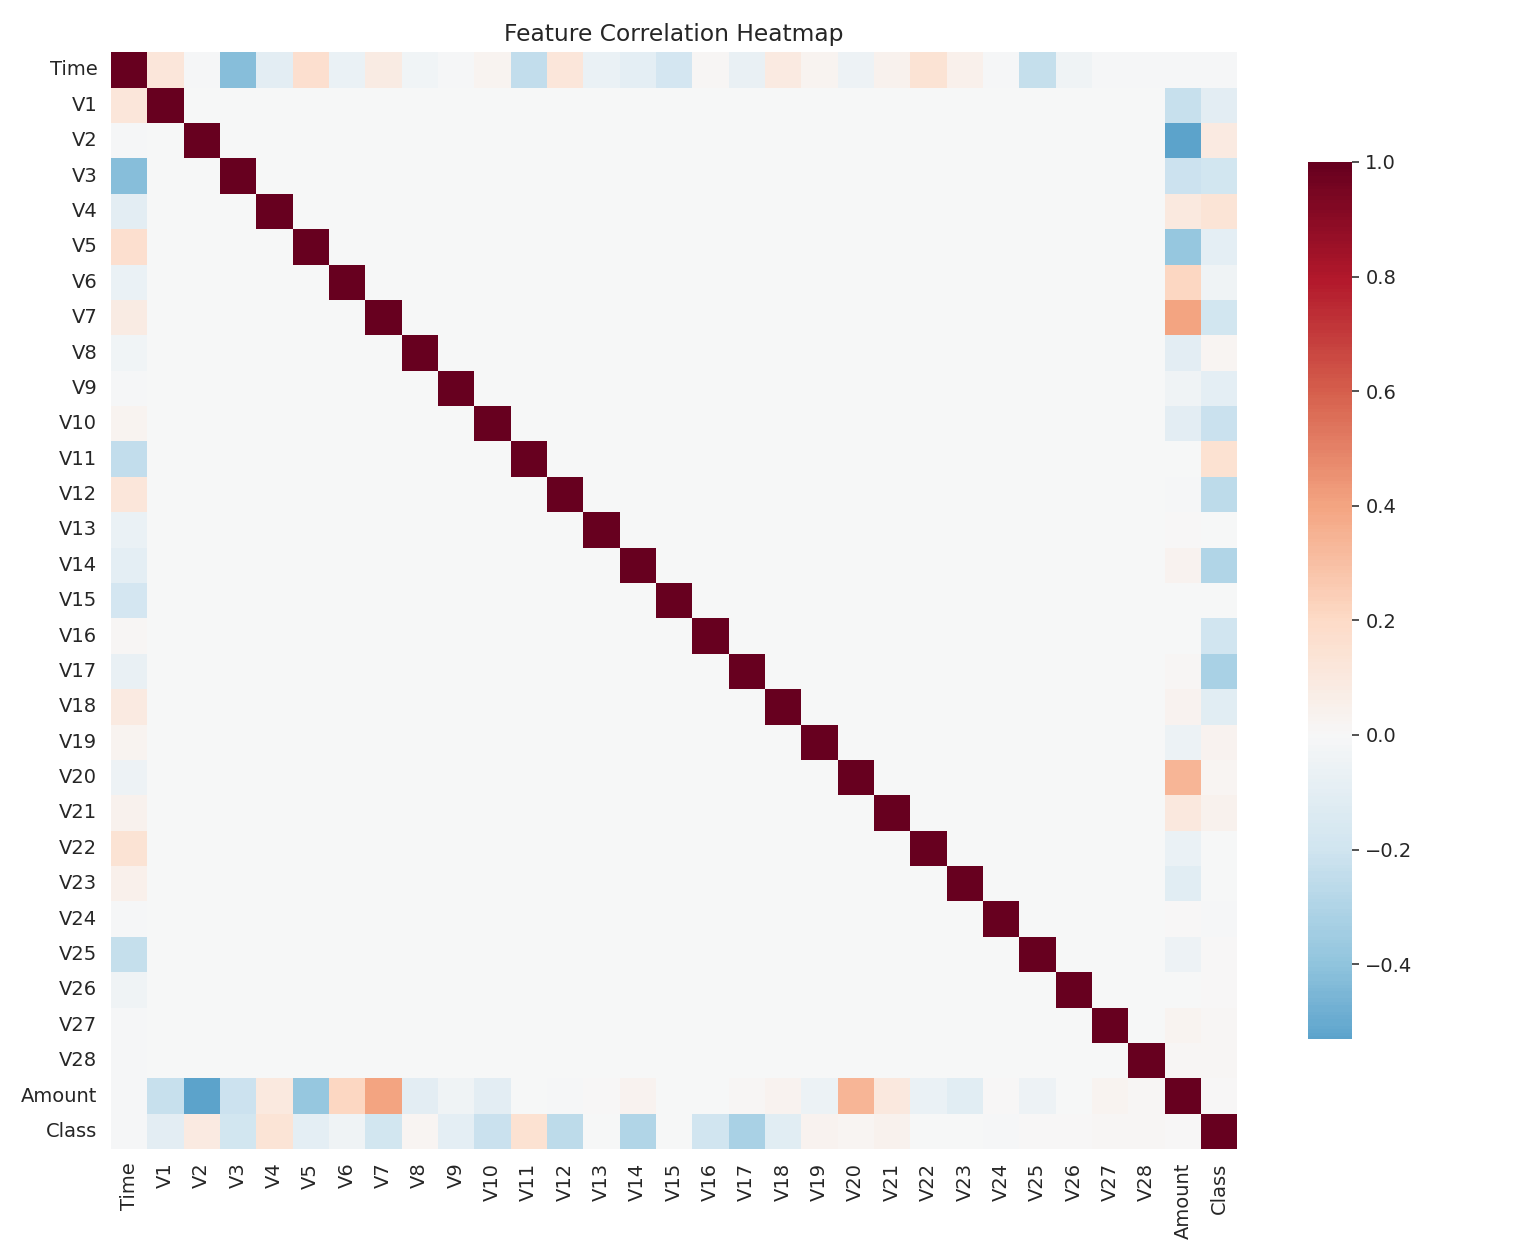

In [1]:
fig, ax = plt.subplots(figsize=(11,9))
corr = df.corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout(); plt.show()

class_corr = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
print("Top 8 features correlated with Class:")
print(class_corr.head(8))

**Finding:** V17, V14, V12 and V10 stand out as the features most correlated with fraud — consistent with widely-published analyses of this dataset — giving both the classifier and the generative model real signal to work with.

## 1.5 PCA projection — does fraud actually separate from non-fraud?

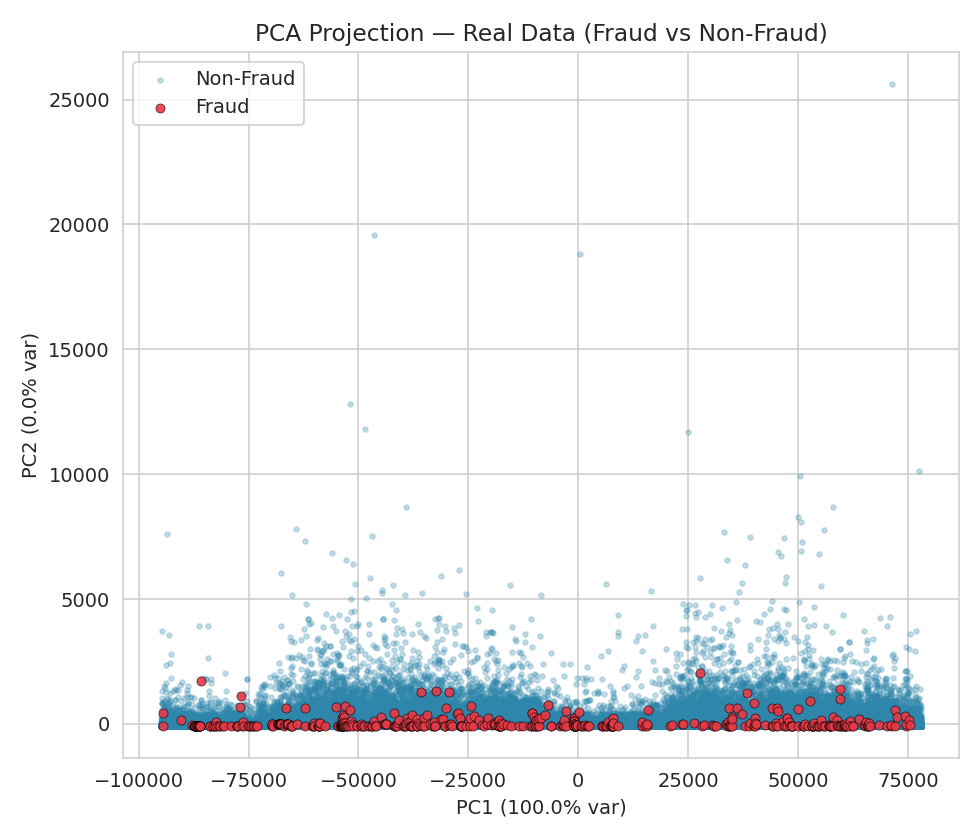

In [1]:
feature_cols = [c for c in df.columns if c != "Class"]
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(df[feature_cols])

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(pcs[df["Class"]==0,0], pcs[df["Class"]==0,1], s=6, alpha=0.25, color=colors[0], label="Non-Fraud")
ax.scatter(pcs[df["Class"]==1,0], pcs[df["Class"]==1,1], s=22, alpha=0.9, color=colors[1],
           label="Fraud", edgecolor="black", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA Projection — Real Data (Fraud vs Non-Fraud)")
ax.legend(); plt.tight_layout(); plt.show()

## 1.6 EDA Summary


Total transactions: 284,807
Fraud cases: 492 (0.1727%)
Imbalance ratio: 1:577
Missing values: 0  
Duplicate rows: 1,081 (known dataset characteristic)
Most fraud-correlated features: V17, V14, V12, V10
